In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [2]:
fidelity_2A0_7 =  [-0.9917788928010864, -0.9982357064340024, -0.9996585477639343, -0.9996849518065586,
-0.9998665245303485, -0.9997101867150098]
drive_param_2A0_7 =  [[0.02331152044796871, 0.023405565749583922, 213.8123185180231, -0.007122098835056658, -0.0066484582383346535],
[0.03982670123286805, 0.01762844075535632, 332.7015596588667, -0.008064469446929902, -0.012298288262487569],
[0.03902324867515039, 0.014124225552434668, 423.1858100136741, -0.007157149909724638, -0.011387631702414148],
[0.012725297523478426, 0.03305550894645792, 557.5633185873248, -0.01570063529126048, -0.011163139582473733],
[0.012304924729586544, 0.03625447605240378, 635.430987524929, -0.018896610271028187, -0.013856868890383825],
[0.0390616233772518, 0.012107754152741082, 716.269924425223, -0.012290116964105655, -0.01465467890130184]]

In [3]:
fidelity_2A0_x0_2 =  [-0.9450622816785093, -0.9721210836906324, -0.9860895123791422, -0.9918671122192713,
-0.9945877207405169, -0.9958769437460324, -0.996768221050478, -0.9971694512643385, -0.997790971867464,
-0.998190253148271, -0.9980385753026282, -0.9986963616516832, -0.9987233375424861, -0.9989101468373811,
-0.9989655226062053, -0.9990863388305202, -0.999162749959455, -0.9990680935360224, -0.999301383146217,
-0.9993390987270072, -0.9992741785821362, -0.9995106293203172, -0.9993925516494946, -0.9994199495424718]
drive_param_2A0_x0_2 =  [[0.0381166737405052, 0.0355915625790964, 129.06942799822227, -0.015622882836263776, -0.014678088318915306],
[0.03286681748965985, 0.030573808138841554, 157.71354115688217, -0.01234241020144287, -0.011521252918384753],
[0.02669552688387878, 0.026662014161782634, 187.31090481285077, -0.009297976978862714, -0.008578661256467184],
[0.022967883411671126, 0.022421575075120718, 216.41763968806274, -0.006533032927623035, -0.006033192366060473],
[0.019689544835639994, 0.019713739656528114, 243.74087174597483, -0.004925773493003363, -0.0046571117679217134],
[0.017292331598932266, 0.017112683943675707, 274.1650771962284, -0.003843696739245968, -0.003656431877802029],
[0.015643541999459592, 0.015445777321513369, 300.8097556356632, -0.003026750944939578, -0.002817196259732471],
[0.014018249979141317, 0.01401663013609888, 329.47951157465076, -0.002479044939738082, -0.0024124752597671374],
[0.013133541078748662, 0.01299127983353874, 354.7569701394594, -0.0021352277263640557, -0.002012523580479604],
[0.01178278088125364, 0.01192760593379397, 385.7935100833866, -0.001815593138492326, -0.0016947978812224922],
[0.011489486952745872, 0.011129915695759765, 404.35823767416645, -0.001573151300034088, -0.0015007707989273828],
[0.010229390606610241, 0.010225716572583534, 445.03249734216917, -0.0013451646048746515, -0.001240234038375379],
[0.009601288648131305, 0.009416759172966227, 476.8434148520623, -0.0011473888138911377, -0.001087816139660908],
[0.009136858689204582, 0.009090842045704399, 501.32634753524997, -0.001043171603458232, -0.000999178507999722],
[0.008413582555541388, 0.008386368698870661, 535.2580202977682, -0.0008750555937096817, -0.0008102522700076439],
[0.008266775194475677, 0.008259670430835222, 549.9242100789731, -0.0008993130836169524, -0.000827862941734649],
[0.00766778529439251, 0.007634431494057349, 589.1104204078268, -0.0007139376912250802, -0.0006583979699465656],
[0.00728511667830857, 0.007369371541591811, 623.80823731083, -0.0006849772902289743, -0.000640685346496233],
[0.007070184514997413, 0.007164903287960359, 635.6390356256247, -0.0006384259206609916, -0.0005877189804060975],
[0.006583985531154779, 0.006617070095131126, 680.9692185930751, -0.0005230380487035308, -0.0005005578373808751],
[0.006523487692003515, 0.006523487692003515, 691.0266744208469, -0.0005193310668362792, -0.0005193310668362792],
[0.006120706736142538, 0.006093852422083471, 738.6184209254957, -0.0004679556458422572, -0.00042656621536297547],
[0.005938864303736803, 0.005938864303736803, 760.76318597172, -0.00043410563429241954, -0.00043410563429241954],
[0.005718650638369904, 0.005718650638369904, 787.4597105231765, -0.000388137139239934, -0.000388137139239934]]

In [4]:
fidelity_2A0_add_x0 =  [-0.9449208697327014, -0.9722034940019533, -0.9856381645292075, -0.9915801384125393,
-0.9927986155679331, -0.9950426063743671, -0.9938953166691844, -0.9874223580466325,
-0.9990438607235802, -0.9967491425739347, -0.9997041932654348, -0.9987027261550635,
-0.9990278722368352, -0.9977814333573196, -0.9995793221060587, -0.9996008565779174,
-0.9997475136424626, -0.999714982385813, -0.9999617496095154, -0.9998553860167518,
-0.9999669781175242, -0.9993870298850268, -0.9998815831479687, -0.9999743616792044]
drive_param_2A0_add_x0 =  [[0.03796592706384106, 0.03466754374172118, 129.1084906045119, -0.015033023136274692, -0.014260719134565655],
[0.031781483643628164, 0.02932028993136357, 158.06379953120114, -0.011164987327736946, -0.010580300671004036],
[0.027736994979108653, 0.02658565377057935, 187.19360853180297, -0.00922770510288987, -0.008920842261521553],
[0.02320622846483133, 0.022673891177512583, 215.68535677452718, -0.006691408693839178, -0.006164225400234851],
[0.022100654917148715, 0.02153763535054546, 224.7002737681801, -0.006221615914507723, -0.005828668519489932],
[0.018147766973546392, 0.01847938118072573, 265.78297541851424, -0.004450148164924459, -0.004137309728628298],
[0.03995671476167617, 0.01974224102323443, 293.64027634574535, -0.008596818279614546, -0.012747788782259026],
[0.01783519010717966, 0.029710152852458895, 323.34263833924155, -0.012502876350562917, -0.008729272393918295],
[0.03974541512446167, 0.01705043922719813, 351.30296723313336, -0.00826899882543511, -0.012279313189478],
[0.017887127787286176, 0.0378634145716619, 385.5667658797259, -0.019813969653090006, -0.014596109059477853],
[0.039680141230466114, 0.014945265976419072, 404.2992827121325, -0.008018438891881063, -0.012044926585565037],
[0.015850042471887284, 0.03773770506957167, 441.7088467595328, -0.019714054255628485, -0.014431406629135972],
[0.015030998276775714, 0.03557434009522749, 462.05670140416305, -0.017610820996714585, -0.012531519702510392],
[0.011678846282274547, 0.027687403779351957, 482.84454532524046, -0.010412366663867053, -0.005864077399232946],
[0.013166160284692132, 0.03445395914851089, 526.1691837740523, -0.01663187218223066, -0.011683087414463705],
[0.012767456226550119, 0.03281974169159556, 553.8515507254439, -0.015574893751215426, -0.011120057177501657],
[0.012097966845275766, 0.032193182099395784, 584.1750470511134, -0.01494931857070291, -0.010487812619525584],
[0.011335276430182156, 0.03443374454499824, 609.4410318034555, -0.016070679156754218, -0.010156724803241557],
[0.011813085613355872, 0.0374298536469591, 651.8796656077302, -0.019556911289750276, -0.013918428292138168],
[0.039966418396765464, 0.013144620779422637, 662.8660418873194, -0.013193383128990382, -0.015483340782641235],
[0.01129307957279239, 0.03800017222501414, 691.6610124580084, -0.01993282201257144, -0.013847058552005426],
[0.013196895491966856, 0.035359621279174046, 715.93575211877, -0.010952573604476174, -0.004965891805227476],
[0.03764202916835974, 0.012505759756557364, 767.5084018616226, -0.013639703391804137, -0.015464086169158075],
[0.01102441078783007, 0.03482359736940192, 779.310805625434, -0.01842845780382138, -0.014166739877120485]]

In [5]:
# i = fidelity_2A0_add_x0.index()
i = 10
print(fidelity_2A0_add_x0[i])
print(drive_param_2A0_add_x0[i])

-0.9997041932654348
[0.039680141230466114, 0.014945265976419072, 404.2992827121325, -0.008018438891881063, -0.012044926585565037]


In [6]:
fidelity_2A0_2detune =  [-0.9444705256146338, -0.9723285851150234, -0.9847031356473263, -0.9906793325868083,
 -0.9940814967133516, -0.9942789354392634, -0.9924520855352995, -0.9970184021466257,
 -0.9938170106436909, -0.9950686116635193, -0.9981808707961282, -0.9990078817893366,
 -0.9989355919151904, -0.9994680712830342, -0.999622506090064, -0.9997725007435022,
 -0.9995561903639499, -0.9997878708114323, -0.9997519048180505, -0.9999098088976058,
 -0.9999329590597285, -0.9998533954513487, -0.9999156883088485, -0.9999410480727681]
drive_param_2A0_2detune =  [[0.039508827869220504, 0.035010784993424734, 128.8799452846599, -0.015386035696256429, -0.01475957859322135],
[0.031920454682963284, 0.03092673916403385, 157.90396963609786, -0.012129382664436496, -0.01155164524023021],
[0.028064082732257627, 0.02703799810304348, 182.4854288986166, -0.009614375046301912, -0.008890600386593934],
[0.02383969360344849, 0.024180091610491106, 209.97643511893804, -0.007758820340942936, -0.007091882148962309],
[0.020576436548975497, 0.020348169435478906, 235.67231152510828, -0.005327396232379527, -0.004971062483462063],
[0.019532133567797542, 0.019678835298391237, 250.57170019069693, -0.005174128528871318, -0.004755136934287894],
[0.039644847113353865, 0.02004739615576714, 300.3014944073696, -0.010074782340081682, -0.013467371608112334],
[0.014530319229647011, 0.014765346469916469, 318.3501156807235, -0.0027177267331231847, -0.002604087193761695],
[0.018358810302692402, 0.03829046976041414, 362.44391505355645, -0.01984964238033559, -0.014213615205081964],
[0.017224886030528658, 0.03652187026887467, 388.0586691892209, -0.018762279799093385, -0.013988841827684975],
[0.016670272191927422, 0.03719021319344679, 419.0210940706081, -0.01922762868115745, -0.014173330146497083],
[0.015496882384720485, 0.03695639489288546, 447.5809863338947, -0.018875869982151662, -0.013602293834085484],
[0.014793705833635512, 0.03732667144219951, 471.88113917164065, -0.019110976755605944, -0.013638899422279882],
[0.014049244044390967, 0.034497168814501857, 498.6405985318976, -0.016747129533552313, -0.011921615361095683],
[0.03971869620190763, 0.013907614243031512, 517.7709602685871, -0.010559564719425102, -0.013560767242752608],
[0.0396347901951397, 0.013988218445034313, 550.7915527999398, -0.011392183069111755, -0.014104960873764344],
[0.037190702768566314, 0.012974253210230062, 580.6236368832127, -0.010240131918849907, -0.01283414803106489],
[0.011408896286783347, 0.0323625599967174, 615.8570152642723, -0.014815784945584904, -0.010075388571710196],
[0.03487758193931325, 0.011651009298965889, 653.6720100226771, -0.009158258166379048, -0.011611258735449504],
[0.03803152828029711, 0.012892187222349074, 665.8077386658774, -0.012140199300096549, -0.014366652702881183],
[0.011274484861023762, 0.03531055237555283, 684.3634935864325, -0.017879128818779597, -0.012847682453605876],
[0.00820877531535667, 0.025858714012572552, 727.3314204459725, -0.009097104911855662, -0.004340801590976034],
[0.03582994975294708, 0.011312880629247582, 749.3964075499988, -0.010832407183059986, -0.012997402531190092],
[0.008911012578562083, 0.028811884708747966, 794.2944644286055, -0.012119730306417229, -0.007872122187454873]]

In [7]:
fidelity_1A0_2detune =  [-0.9372429162326494, -0.9677766646742946, -0.9827831537039342, -0.9894979385510012,
-0.9927149187363117, -0.9945544649950591, -0.9957451789902448, -0.996536966103044, -0.9971624129535244,
-0.9976084440343607, -0.9979457168996051, -0.9981674668301859, -0.9984376285327153, -0.9986180695404225,
-0.9987713088093042, -0.9988158999586576, -0.9990161072221359, -0.9991065324988396, -0.9991882046462763,
-0.9992429798271412, -0.9940858569149584, -0.9945171511388912, -0.999329314074112, -0.9994580771385557]
drive_param_1A0_2detune =  [[0.03623044951769749, 129.13056871080468, -0.0150106275980803],
[0.030837619286900014, 158.29020272689684, -0.011356746153072615],
[0.026195362822052877, 187.46915070857352, -0.008378407862101629],
[0.02237028000639424, 216.57818589364237, -0.006238170903217155],
[0.019490636467725215, 245.3074899005092, -0.004704807223271641],
[0.017078230662447003, 274.4290974032532, -0.003595850096250102],
[0.015332516383787652, 303.7611887876717, -0.0029284320250105925],
[0.01382683903906485, 333.15300089868373, -0.0023308739548992],
[0.012694972363278552, 362.3268329873799, -0.0019788014216602567],
[0.011699695438399299, 391.3047902932359, -0.001681832771269911],
[0.010886095787472738, 420.06958504181677, -0.0014638848067459987],
[0.010145366159780967, 449.09825131156464, -0.0012932714869559115],
[0.009513967548022695, 479.08341805164446, -0.0011104311693879154],
[0.008935700331676188, 508.2876588799988, -0.0009682533288695083],
[0.008441686960920958, 536.7058460989456, -0.0008827133568652457],
[0.008046482319927575, 565.9284552589534, -0.0008131606828541038],
[0.007586897201696686, 595.8156535922149, -0.0007081633790778641],
[0.00723678056493576, 624.7267665119377, -0.0006364638552920288],
[0.0069140121722948665, 653.4424881094328, -0.0005835103609514936],
[0.006622622954774428, 682.619098414595, -0.0005296273156749854],
[0.010862455158201804, 712.3017647252458, -0.0030754629148799827],
[0.010433095318627367, 740.9278119267435, -0.0029242886149549886],
[0.005859497616067671, 769.9745263173477, -0.0003992539626489711],
[0.005625951762472537, 799.7332234246925, -0.0003831912471068266]]

In [8]:
fidelity_no_tg = [-0.8992716730533473, -0.9659292211506513, -0.9827466731014785, -0.9895102114347528,
-0.992695367201072, -0.9945632658722475, -0.9957396603015596, -0.9964422646663855,
-0.9971597341241264, -0.9975719577517881, -0.9978953009602021, -0.9982075707312003,
-0.9984293156264531, -0.9986117278797988, -0.9987620772014856, -0.998851639882276,
-0.9990000444781817, -0.9990624223110617, -0.9991888038341937, -0.9992158110685763,
-0.9993160670395141, -0.9993678192121846, -0.999407135441265, -0.9994103462280863]
drive_param_no_tg = [[0.02999474816352026, 129.1500419800744, -0.009292329642103483],
[0.029530693046782845, 158.1577805617266, -0.009977307342832573],
[0.026512804889699787, 187.44103807280143, -0.008661325199722885],
[0.022371326840034792, 216.51945487324213, -0.006209279151158805],
[0.01928153334518798, 245.5414853390687, -0.004591960994539342],
[0.017143732282708494, 274.3626755267213, -0.0036307822044814335],
[0.015361984950676418, 303.35694175846123, -0.002911162341539972],
[0.013990190839843158, 333.06362324655277, -0.0024047565692946215],
[0.01269535596570279, 362.0355442330688, -0.0019818189327212134],
[0.011734534373562757, 390.9646336439722, -0.0017228825051639942],
[0.010810947064192465, 420.6486868924635, -0.0014519273910586251],
[0.010106693906372644, 449.3985839571423, -0.001252789353741809],
[0.009483306747750902, 478.93504950704806, -0.0011186118227505494],
[0.008916966019391181, 507.95650192674157, -0.0009633203427256432],
[0.008442724437444659, 537.3703966799278, -0.0008612267060327181],
[0.008031525948156155, 566.5857234889115, -0.0007881789100705359],
[0.007580960026208975, 595.1333105985577, -0.000698617153155957],
[0.0072408174654952535, 624.0509064105993, -0.0006598979005994323],
[0.006904058356693629, 653.9263102263819, -0.0005804847453868903],
[0.006623661100961494, 682.8677494179104, -0.0005520053604480711],
[0.006346486750209549, 711.567815739258, -0.0004915403246768743],
[0.006083538097012044, 741.2953553285831, -0.0004576030127480344],
[0.005842594187721272, 770.8220958702152, -0.00042427967746907786],
[0.0056248381339795255, 799.4526118605029, -0.0003991591602852647]]

In [9]:
fidelity_2A0= [-0.9011669253626609, -0.9690877252216795, -0.9859184325450201, -0.9916342364684514,
 -0.9944941544595721, -0.9954618571624971, -0.9854691692941501, -0.9971785758251656,
 -0.990683712697064, -0.9922113481047552, -0.9939004992942346, -0.9961096719562075,
 -0.9973853142675416, -0.9986264491089694, -0.9991518954432763, -0.9975154800195154,
 -0.9993987133935264, -0.9988550989985094, -0.9991468788749168, -0.9994452113512866,
 -0.9996265486110726, -0.9995322190751812, -0.9996661059428869, -0.9999582621863172]
drive_param_2A0=[[0.029964203185469607, 0.029945019559664842, 129.15600923466874, -0.009958421728936871, -0.00907583816429548],
[0.029914705557748673, 0.028711771024391056, 157.6262942074708, -0.009826168691505328, -0.009359214212940729],
[0.026480020158372728, 0.0262846244843435, 186.9482461384547, -0.008862259109147287, -0.008076632034179812],
[0.022705574076491025, 0.022487775826874952, 216.6269089841166, -0.006437898337737148, -0.006237681136067863],
[0.01955942331340678, 0.019875777880695125, 245.33006150931615, -0.005030477679996387, -0.0047643868809864],
[0.017031016859075578, 0.017176823827041575, 274.8290932274558, -0.003926331752166842, -0.0035693652618258532],
[0.02986763793702233, 0.01959910067979876, 303.7238879625338, -0.007760427072886191, -0.009592969918123865],
[0.013882342784834857, 0.013746866159428954, 332.3907530555527, -0.0023236194513657584, -0.0021667599307659048],
[0.016043367216116596, 0.026065727117923897, 362.3266609913932, -0.009957561756719049, -0.006960224450043585],
[0.029383806227648097, 0.01577861215623299, 391.3026113839661, -0.006483355540233004, -0.008674942021137805],
[0.013797500112514936, 0.025947243388459846, 420.4711889982943, -0.009733387748451179, -0.006329544625295015],
[0.01288700356056509, 0.02657834471353713, 449.4410363954888, -0.009970799954895823, -0.006262713803065349],
[0.012218742153585808, 0.025877544337004316, 478.9597994117047, -0.00960762396026447, -0.005986844213655604],
[0.011382191339510222, 0.026658608257888218, 508.17095256825695, -0.009951111495642873, -0.005858849667933797],
[0.010740729613529395, 0.025579199654977427, 536.677946041256, -0.009225875683992347, -0.00533418556727214],
[0.02904432877705177, 0.011451716509729443, 566.2238074897958, -0.006073582998017765, -0.008412451190806641],
[0.009815130963694216, 0.02549022941193498, 595.0349743943236, -0.009157966469637447, -0.005086824430698132],
[0.02925946269886979, 0.010264334044360147, 624.0171794580832, -0.005444121460099321, -0.008037074696212114],
[0.029961580622437554, 0.010462535040861963, 653.9948367219633, -0.006317554135810908, -0.008744705709732506],
[0.029800386449773213, 0.009854021064212442, 682.7035427635767, -0.005992882697665659, -0.008478764553659854],
[0.008150830638699917, 0.02397342499391277, 712.0430659588491, -0.00816095790285023, -0.0043415722631706],
[0.029754783335748256, 0.009965090496883273, 741.4859678355775, -0.006997122253886897, -0.009145539462139779],
[0.007607305116235611, 0.023598300478019182, 770.3784927478033, -0.007960544121069254, -0.004080454717552032],
[0.007669186162105274, 0.027084450360314285, 799.1621509065542, -0.009766467635299637, -0.0042042736767885554]]

In [10]:
fidelity_0614 =  [-0.8989411464799787, -0.9653740764850867, -0.9826198013368124, -0.9894571611486587,
 -0.9925044785631958, -0.9944383625013492, -0.9955071328320377, -0.9964676896723785,
 -0.9969912079517667, -0.9974752301119587, -0.9977277682266991, -0.9981604624151773,
 -0.9984142900111748, -0.998586453152724, -0.9987728764336886, -0.9988176074582107,
 -0.9989946001593848, -0.9990616339537144, -0.9990781102760872, -0.999232051183143,
 -0.9992741785821361, -0.9993472661267437, -0.999392551649494, -0.9994199495424718]
drive_param_0614 =  [[0.02998763398547402, 129.060364854945, -0.009524334449526474],
 [0.029493350591334434, 157.71779952810067, -0.009941382763999338],
 [0.025950915455974895, 187.30292652442327, -0.00821681040657746],
 [0.022534777844595476, 216.42619098890876, -0.006268319044336534],
 [0.019572332065418703, 243.7496949100433, -0.004686625611314125],
 [0.01700764083302345, 274.1637763512114, -0.003590807111667511],
 [0.015643541999459592, 300.81632686689034, -0.003026750944939577],
 [0.014080775914738629, 329.4778392022009, -0.0024729159770241482],
 [0.012941227938039604, 354.7592332298872, -0.0020370898504066593],
 [0.011829096115033699, 385.78884937994235, -0.0017382166860813444],
 [0.011257929230028885, 404.36043366270167, -0.0015458429030142506],
 [0.010279964335750055, 445.0323390656677, -0.0013057734346887317],
 [0.009513295140347789, 476.83700141609415, -0.0011199238032474656],
 [0.009046422511480925, 501.3241321052972, -0.0010093707724371384],
 [0.008466852336793954, 535.2523726323412, -0.0008810170202933889],
 [0.00822939850536708, 549.9230118770298, -0.0008156841033343572],
 [0.007675580940429315, 589.106942356207, -0.0007218788768798149],
 [0.007247654633780758, 623.8079249944897, -0.0006615194170941016],
 [0.007084520133174579, 635.6321429096266, -0.0005958385713969502],
 [0.0066357557646690764, 680.9737743178056, -0.0005502122424595225],
 [0.006523487692003517, 691.0266744208469, -0.0005193310668362792],
 [0.006091476575864481, 738.6159881855083, -0.00044466628394118114],
 [0.005938864303736805, 760.76318597172, -0.00043410563429241867],
 [0.005718650638369904, 787.4597105231765, -0.00038813713923993576]]

In [15]:
fidelity_0628 =  [-0.9946844262591625, -0.9982586505184324, -0.9991245170397074, -0.9953379024944169]
drive_param_0628 =  [[0.016846169867731083, 274.10443761528995, -0.0036351074366990123],
[0.009912604605981961, 449.36596419733286, -0.0012340373158765774],
[0.007089160107792949, 624.0880968083354, -0.0006302475074800463],
[0.009493997203097751, 799.5058577061732, -0.002629631459332148]]


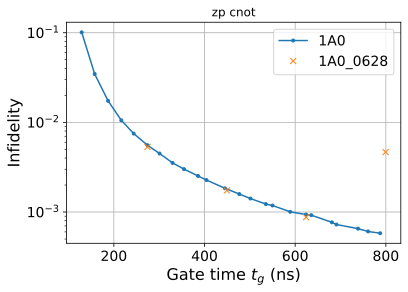

In [16]:
Infidelity_2A0_7 = 1+np.array(fidelity_2A0_7)
Infidelity_2A0_x0_2 = 1+np.array(fidelity_2A0_x0_2)
Infidelity_2A0_add_x0 = 1+np.array(fidelity_2A0_add_x0)
Infidelity_2A0_2detune = 1+np.array(fidelity_2A0_2detune)
Infidelity_1A0_2detune = 1+np.array(fidelity_1A0_2detune)
Infidelity_no_tg = 1+np.array(fidelity_no_tg)
Infidelity_2A0 = 1+np.array(fidelity_2A0)
Infidelity_0614 = 1+np.array(fidelity_0614)
Infidelity_0628 = 1+np.array(fidelity_0628)
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(np.array(drive_param_0614)[:,1], Infidelity_0614, '.-', label='1A0')
plt.plot(np.array(drive_param_0628)[:,1], Infidelity_0628, 'x', label='1A0_0628')
# plt.plot(np.array(drive_param_no_tg)[:,1], Infidelity_no_tg, 'x', label='1A0_no_tg')
# plt.plot(np.array(drive_param_1A0_2detune)[:,1], Infidelity_1A0_2detune, '+', label='1A0_2detune')
# plt.plot(np.array(drive_param_2A0_2detune)[:,2], Infidelity_2A0_2detune, '.-', label='2A0_2detune')
# plt.plot(np.array(drive_param_2A0_add_x0)[:,2], Infidelity_2A0_add_x0, '.-', label='2A0_x0_1')
# plt.plot(np.array(drive_param_2A0_x0_2)[:,2], Infidelity_2A0_x0_2, '.-', label='2A0_x0_2')
# plt.plot(np.array(drive_param_2A0_7)[:,2], Infidelity_2A0_7, '.-', label='2A0_7')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity')
plt.title('zp cnot')
plt.grid()
plt.legend()

In [ ]:
=

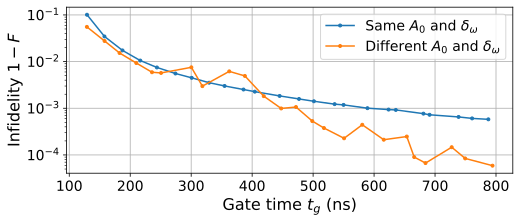

In [14]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(np.array(drive_param_0614)[:,1], Infidelity_0614, '.-', label='Same $A_0$ and $\delta_\omega$')
plt.plot(np.array(drive_param_2A0_2detune)[:,2], Infidelity_2A0_2detune, '.-', label='Different $A_0$ and $\delta_\omega$')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.title('zp cnot')
plt.grid()
plt.legend()
# plt.savefig('cnot_fidelity_2A0_and_1A0.png',dpi=300,bbox_inches='tight')

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
tg_vec = np.linspace(100, 800, num=25)
tg_bounds = []
for i in range(len(tg_vec)-1):
    tg_bounds.append((tg_vec[i], tg_vec[i+1]))
tg_bounds

[(100.0, 129.16666666666666),
 (129.16666666666666, 158.33333333333334),
 (158.33333333333334, 187.5),
 (187.5, 216.66666666666669),
 (216.66666666666669, 245.83333333333334),
 (245.83333333333334, 275.0),
 (275.0, 304.1666666666667),
 (304.1666666666667, 333.33333333333337),
 (333.33333333333337, 362.5),
 (362.5, 391.6666666666667),
 (391.6666666666667, 420.83333333333337),
 (420.83333333333337, 450.0),
 (450.0, 479.1666666666667),
 (479.1666666666667, 508.33333333333337),
 (508.33333333333337, 537.5),
 (537.5, 566.6666666666667),
 (566.6666666666667, 595.8333333333334),
 (595.8333333333334, 625.0),
 (625.0, 654.1666666666667),
 (654.1666666666667, 683.3333333333334),
 (683.3333333333334, 712.5),
 (712.5, 741.6666666666667),
 (741.6666666666667, 770.8333333333334),
 (770.8333333333334, 800.0)]

In [ ]:
tg_vec = np.linspace(100, 800, num=25)
tg_bounds = []
for i in range(len(tg_vec)-1):
    tg_bounds.append((tg_vec[i+1]-1, tg_vec[i+1]))
tg_bounds

[(128.16666666666666, 129.16666666666666),
 (157.33333333333334, 158.33333333333334),
 (186.5, 187.5),
 (215.66666666666669, 216.66666666666669),
 (244.83333333333334, 245.83333333333334),
 (274.0, 275.0),
 (303.1666666666667, 304.1666666666667),
 (332.33333333333337, 333.33333333333337),
 (361.5, 362.5),
 (390.6666666666667, 391.6666666666667),
 (419.83333333333337, 420.83333333333337),
 (449.0, 450.0),
 (478.1666666666667, 479.1666666666667),
 (507.33333333333337, 508.33333333333337),
 (536.5, 537.5),
 (565.6666666666667, 566.6666666666667),
 (594.8333333333334, 595.8333333333334),
 (624.0, 625.0),
 (653.1666666666667, 654.1666666666667),
 (682.3333333333334, 683.3333333333334),
 (711.5, 712.5),
 (740.6666666666667, 741.6666666666667),
 (769.8333333333334, 770.8333333333334),
 (799.0, 800.0)]

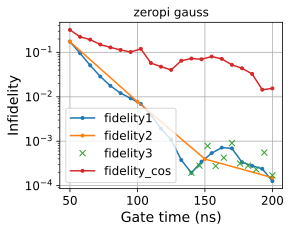

In [ ]:
fidelity1 =  [-0.8261300222983078, -0.9045784509656543, -0.9489376922824411, -0.9714305288611247, -0.9823695276522079,
 -0.9879347132926529, -0.9907903024272885, -0.9931041305728288, -0.9960471619165142, -0.9980861783074385,
 -0.9989228604529586, -0.999622719709984, -0.9998053306021208, -0.9996531216685932, -0.9994613684263965,
 -0.9992828596191771, -0.9993103293117456, -0.9996650222791118, -0.9997206357026581, -0.9997610070701427,
 -0.9998734074801799]

fidelity2 = [-0.8261309755108878, -0.9922221133233075, -0.9996035644742648, -0.999848817803595]

fidelity3 =  [-0.9998053306021213, -0.9997180732540427, -0.9992149673074362, -0.9997232197536379, -0.9995746479357921, -0.9990940935525735, -0.9996849474157358, -0.9997185105757783, -0.9997681961892558, -0.9994437913571058, -0.999829679763298]

fidelity_cos =  [-0.6792381909612608, -0.7762918897184613, -0.8063147392088359, -0.850049574910282, -0.870751610131439, -0.8865012112195487, -0.8981940783043161, -0.8798756597406548, -0.942512543947362, -0.9524274174540983, -0.9596829961564239, -0.9352459113115813, -0.9273114625731802, -0.93002749429125, -0.9195755725560298, -0.9286553122063061, -0.9475315646660343, -0.9561926775512545, -0.9673074512248003, -0.9855762570484545, -0.9845504545918843]




fidelity1 = 1+np.array(fidelity1)
fidelity2 = 1+np.array(fidelity2)
fidelity3 = 1+np.array(fidelity3)
fidelity_cos = 1+np.array(fidelity_cos)
tg_vec1 = np.linspace(50, 200, num=21)
tg_vec2 = np.linspace(50, 200, num=4)
tg_vec3 = np.linspace(140, 200, num=11)

fig, ax = plt.subplots(figsize=(4,3))
plt.plot(tg_vec1, fidelity1, '.-', label='fidelity1')
plt.plot(tg_vec2, fidelity2, '.-', label='fidelity2')
plt.plot(tg_vec3, fidelity3, 'x', label='fidelity3')
plt.plot(tg_vec1, fidelity_cos, '.-', label='fidelity_cos')
plt.yscale('log')
plt.xlabel('Gate time (ns)')
plt.ylabel('Infidelity')
plt.title('zeropi gauss')
plt.grid()
plt.legend()